## Setup & Environment

Install required libraries, check GPU, and mount Google Drive.

In [ ]:
!pip -q install -U peft

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/Project2_preprocessing_mal_en/clean_train.csv")
dev   = pd.read_csv("/content/drive/MyDrive/Project2_preprocessing_mal_en/clean_dev.csv")
test  = pd.read_csv("/content/drive/MyDrive/Project2_preprocessing_mal_en/clean_test.csv")

print("Train shape:", train.shape)
print("Dev shape:",   dev.shape)
print("Test shape:",  test.shape)

Train shape: (4840, 3)
Dev shape: (540, 3)
Test shape: (1347, 3)


In [ ]:
# Keep only Positive and Negative
train = train[train["category"].isin(["Positive", "Negative"])]
dev   = dev[dev["category"].isin(["Positive", "Negative"])]
test  = test[test["category"].isin(["Positive", "Negative"])]

print("Filtered Train shape:", train.shape)
print("Filtered Dev shape:",   dev.shape)
print("Filtered Test shape:",  test.shape)

Filtered Train shape: (2566, 3)
Filtered Dev shape: (275, 3)
Filtered Test shape: (702, 3)


## Convert to mT5 Format

In [ ]:
def convert_to_finetune_format(df):
    formatted = []
    for _, row in df.iterrows():
        formatted.append({
            "input_text":  "sentiment: " + str(row["text"]),
            "target_text": row["category"].lower().strip()
        })
    return formatted

train_data = convert_to_finetune_format(train)
dev_data   = convert_to_finetune_format(dev)
test_data  = convert_to_finetune_format(test)

print(f"Prepared {len(train_data)} train, {len(dev_data)} dev, {len(test_data)} test examples")

Prepared 2566 train, 275 dev, 702 test examples


## Align class balance with full finetuning

In [ ]:
from collections import defaultdict
import random
random.seed(42)

# group examples by label
by_label = defaultdict(list)
for ex in train_data:
    by_label[ex["target_text"]].append(ex)

pos = by_label["positive"]
neg = by_label["negative"]

print("Before oversampling:", len(pos), "pos,", len(neg), "neg")

# Oversample negatives to match positives
if len(neg) < len(pos):
    neg_balanced = neg + random.choices(neg, k=(len(pos) - len(neg)))
else:
    neg_balanced = neg

train_data = pos + neg_balanced
random.shuffle(train_data)

print("After oversampling:",
      sum(1 for x in train_data if x["target_text"]=="positive"), "pos,",
      sum(1 for x in train_data if x["target_text"]=="negative"), "neg")

Before oversampling: 2018 pos, 548 neg
After oversampling: 2018 pos, 2018 neg


## Model + Tokenizer

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/mt5-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
print("Model loaded:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded: google/mt5-small


## PEFT / LoRA (parameter efficient fine tuning)
Attaching LoRA adapters and training adapters while freezing the base mT5 weights.


In [ ]:

from peft import LoraConfig, TaskType, get_peft_model


lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q", "v"],
    bias="none"
)


model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 344,064 || all params: 556,635,520 || trainable%: 0.0618


## Tokenization

In [ ]:
def tokenize_example(example):
    model_input = tokenizer(
        example["input_text"],
        max_length=64,
        padding="max_length",
        truncation=True
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            example["target_text"],
            max_length=8,
            padding="max_length",
            truncation=True
        )

    label_ids = [
        (token if token != tokenizer.pad_token_id else -100)
        for token in labels["input_ids"]
    ]

    model_input["labels"] = label_ids
    return model_input

## Create HuggingFace Datasets

In [ ]:
from datasets import Dataset

# Redefine tokenize_example to fix the AttributeError
def tokenize_example(example):
    model_input = tokenizer(
        example["input_text"],
        max_length=64,
        padding="max_length",
        truncation=True
    )

    # Removed 'with tokenizer.as_target_tokenizer():' as it's deprecated
    labels = tokenizer(
        example["target_text"],
        max_length=8,
        padding="max_length",
        truncation=True
    )

    label_ids = [
        (token if token != tokenizer.pad_token_id else -100)
        for token in labels["input_ids"]
    ]

    model_input["labels"] = label_ids
    return model_input

train_dataset = Dataset.from_list(train_data)
dev_dataset   = Dataset.from_list(dev_data)
test_dataset  = Dataset.from_list(test_data)

tokenized_train = train_dataset.map(tokenize_example)
tokenized_dev   = dev_dataset.map(tokenize_example)
tokenized_test  = test_dataset.map(tokenize_example)

print("Tokenization done.")
print("Train:", len(tokenized_train), "Dev:", len(tokenized_dev), "Test:", len(tokenized_test))

Map:   0%|          | 0/4036 [00:00<?, ? examples/s]

Map:   0%|          | 0/275 [00:00<?, ? examples/s]

Map:   0%|          | 0/702 [00:00<?, ? examples/s]

Tokenization done.
Train: 4036 Dev: 275 Test: 702


## Normalize Labels & Compute Metrics

In [ ]:
import re

ALLOWED_LABELS = {"positive", "negative"}

def normalize_label(text):
    if text is None:
        return "negative"
    text = text.strip().lower()
    text = re.sub(r"\s+", " ", text)
    text = text.split()[0] if text.split() else ""
    return text if text in ALLOWED_LABELS else "negative"

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    if isinstance(preds, tuple):
        preds = preds[0]

    if preds.ndim == 3:
        preds = preds.argmax(-1)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [normalize_label(p) for p in decoded_preds]
    decoded_labels = [normalize_label(l) for l in decoded_labels]

    acc = accuracy_score(decoded_labels, decoded_preds)
    f1_weighted = f1_score(decoded_labels, decoded_preds, average="weighted")
    f1_macro = f1_score(decoded_labels, decoded_preds, average="macro")
    precision_macro = precision_score(decoded_labels, decoded_preds, average="macro", zero_division=0)
    recall_macro = recall_score(decoded_labels, decoded_preds, average="macro", zero_division=0)

    return {
        "accuracy": acc,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
    }

## Training Arguments

Key fixes:
- `eval_strategy='epoch'` so evaluation runs after each epoch
- `predict_with_generate=True` so the seq2seq model generates text for evaluation
- `load_best_model_at_end=True` to keep the best checkpoint
- Added `generation_max_length` to match label length

In [ ]:
from transformers import Seq2SeqTrainingArguments
import torch

training_args = Seq2SeqTrainingArguments(
    output_dir="./outputs",

    # update:enable evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    save_total_limit=2,

    # update:use generate for seq2seq evaluation
    predict_with_generate=True,
    generation_max_length=8,

    learning_rate=3e-4, # higher LR helps small mT5 converge faster
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    fp16=False,
    report_to="none",
)
print("Training args configured.")

Training args configured.


## Trainer

In [ ]:
from transformers import Seq2SeqTrainer, DataCollatorForSeq2Seq

# DataCollator handles dynamic padding properly
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev, # update: pass dev set
    compute_metrics=compute_metrics,# update: pass metrics function
    data_collator=data_collator,
)
print("Trainer ready.")

Trainer ready.


## Train

In [ ]:
train_result = trainer.train()
print("\n=== Training complete ===")
print(f"  Train loss:    {train_result.training_loss:.4f}")
print(f"  Train runtime: {train_result.metrics.get('train_runtime', 0):.1f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision Macro,Recall Macro
1,7.500401,2.945058,0.185455,0.058026,0.156442,0.092727,0.500000
2,3.009725,0.773621,0.814545,0.731295,0.448898,0.407273,0.500000
3,2.101509,0.514086,0.814545,0.731295,0.448898,0.407273,0.500000



=== Training complete ===
  Train loss:    5.9046
  Train runtime: 117.8s


## Save LoRA adapters

In [ ]:
import os

LORA_OUT_DIR = "/content/drive/MyDrive/mt5_lora_malayalam_sentiment"
os.makedirs(LORA_OUT_DIR, exist_ok=True)

# Save only adapters + config (small)
model.save_pretrained(LORA_OUT_DIR)
tokenizer.save_pretrained(LORA_OUT_DIR)

print("Saved LoRA adapters to:", LORA_OUT_DIR)


Saved LoRA adapters to: /content/drive/MyDrive/mt5_lora_malayalam_sentiment


## Evaluate on Dev Set

In [ ]:
dev_metrics = trainer.evaluate(eval_dataset=tokenized_dev)
print("\n=== Dev Set Results ===")
for k, v in dev_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")


=== Dev Set Results ===
  eval_loss: 0.7736
  eval_accuracy: 0.8145
  eval_f1_weighted: 0.7313
  eval_f1_macro: 0.4489
  eval_precision_macro: 0.4073
  eval_recall_macro: 0.5000
  eval_runtime: 1.9493
  eval_samples_per_second: 141.0770
  eval_steps_per_second: 9.2340
  epoch: 3.0000


## Evaluate on Test Set

In [ ]:
# Tokenize test set and run prediction
test_preds = trainer.predict(tokenized_test)

# Decode predictions
raw_preds = test_preds.predictions
if isinstance(raw_preds, tuple):
    raw_preds = raw_preds[0]
if raw_preds.ndim == 3:
    raw_preds = raw_preds.argmax(-1)

decoded_test_preds  = tokenizer.batch_decode(raw_preds, skip_special_tokens=True)
test_labels_arr     = np.where(test_preds.label_ids != -100,
                                test_preds.label_ids,
                                tokenizer.pad_token_id)
decoded_test_labels = tokenizer.batch_decode(test_labels_arr, skip_special_tokens=True)

norm_test_preds  = [normalize_label(p) for p in decoded_test_preds]
norm_test_labels = [normalize_label(l) for l in decoded_test_labels]

test_acc = accuracy_score(norm_test_labels, norm_test_preds)
test_f1  = f1_score(norm_test_labels, norm_test_preds, average="weighted", zero_division=0)

print("\n=== Test Set Results ===")
print(f"  Accuracy:    {test_acc:.4f}")
print(f"  F1 (weighted): {test_f1:.4f}")

# Show a sample of predictions
print("\n--- Sample Predictions (first 10) ---")
for i in range(min(10, len(norm_test_preds))):
    print(f"  Pred: {norm_test_preds[i]:<10}  Gold: {norm_test_labels[i]}")


=== Test Set Results ===
  Accuracy:    0.8034
  F1 (weighted): 0.7158

--- Sample Predictions (first 10) ---
  Pred: positive    Gold: negative
  Pred: positive    Gold: positive
  Pred: positive    Gold: negative
  Pred: positive    Gold: negative
  Pred: positive    Gold: positive
  Pred: positive    Gold: negative
  Pred: positive    Gold: positive
  Pred: positive    Gold: positive
  Pred: positive    Gold: negative
  Pred: positive    Gold: positive


In [ ]:
texts = test["text"].tolist()
labels = norm_test_labels
preds = norm_test_preds
correct = []
false_pos = []

for text, pred, gold in zip(texts, preds, labels):
    if pred == gold:
        correct.append((text, pred, gold))
    elif pred == "positive" and gold == "negative":
        false_pos.append((text, pred, gold))

print("Correct predictions:\n")
for t, p, g in correct[:10]:  # limit so it doesn't print everything
    print(f'"{t}", Predicted: {p} | Gold: {g}\n')

print("\nFalse positives (false predictions):\n")
for t, p, g in false_pos[:10]:
    print(f'"{t}", Predicted: {p} | Gold: {g}\n')

Correct predictions:

"Njan antarticail ninnanu malayalam ariyilla trailer adipoli", Predicted: positive | Gold: positive

"Nta ponnu muthu maniyeeee lalataaaaaaaaaaa", Predicted: positive | Gold: positive

"Ente ponnu mammoooka mass item veendum..bgm aanegil onnum choikandaa porichu", Predicted: positive | Gold: positive

"Malayala cinema record thkarkan varunuu athiradi mass movie abrhaminte santhathikal", Predicted: positive | Gold: positive

"Lucifer pole oru nalla chitha maayi maaratte . By lalettan fan", Predicted: positive | Gold: positive

"Ente prthvirajee kettipidich oru ummma thannaoteee chakkarereeee", Predicted: positive | Gold: positive

"Adich keri va makkallee ika polikkmm", Predicted: positive | Gold: positive

"Ella new gen nadan maarum ananju...eth saubin ugam 🥰", Predicted: positive | Gold: positive

"Eattan fanzz koode ind...ninga polikk ikkkaaaa", Predicted: positive | Gold: positive

"Trailer superrrrr ikka pwolikkum padam oru action thriller blockbuster ayirikku

## Confusion matrix (test set)


Map:   0%|          | 0/702 [00:00<?, ? examples/s]

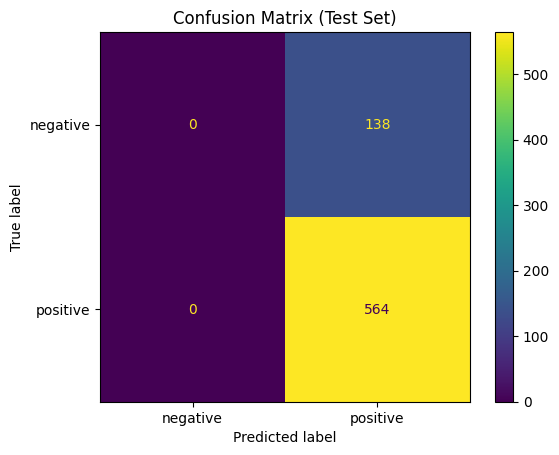

Classification report (Test Set):
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000       138
    positive     0.8034    1.0000    0.8910       564

    accuracy                         0.8034       702
   macro avg     0.4017    0.5000    0.4455       702
weighted avg     0.6455    0.8034    0.7158       702



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

tokenized_test = test_dataset.map(tokenize_example)


test_pred = trainer.predict(tokenized_test)
decoded_preds = tokenizer.batch_decode(test_pred.predictions, skip_special_tokens=True)


label_ids = np.where(test_pred.label_ids != -100, test_pred.label_ids, tokenizer.pad_token_id)
decoded_labels = tokenizer.batch_decode(label_ids, skip_special_tokens=True)


y_pred = [normalize_label(p) for p in decoded_preds]
y_true = [normalize_label(l) for l in decoded_labels]


labels_order = ["negative", "positive"]
cm = confusion_matrix(y_true, y_pred, labels=labels_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print("Classification report (Test Set):")
print(classification_report(y_true, y_pred, labels=labels_order, digits=4, zero_division=0))

## Save Model & Training History

In [ ]:
import os

# Save locally in Colab first, then copy to Drive
save_path = "/content/mt5_finetuned"
os.makedirs(save_path, exist_ok=True)
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved locally to: {save_path}")

# Now copy to Drive
drive_path = "/content/drive/MyDrive/mt5_finetuned"
os.system(f"cp -r {save_path} '{drive_path}'")
print(f"Copied to Drive: {drive_path}")

# Show training log
print("\n--- Training Log History ---")
for entry in trainer.state.log_history:
    relevant = {k: round(v, 4) if isinstance(v, float) else v
                for k, v in entry.items()
                if k in ("epoch", "loss", "eval_accuracy", "eval_f1_weighted",
                         "eval_loss", "train_loss")}
    if relevant:
        print(relevant)

Model saved locally to: /content/mt5_finetuned
Copied to Drive: /content/drive/MyDrive/mt5_finetuned

--- Training Log History ---
{'loss': 14.2745, 'epoch': 0.1976}
{'loss': 12.7624, 'epoch': 0.3953}
{'loss': 11.2, 'epoch': 0.5929}
{'loss': 9.4293, 'epoch': 0.7905}
{'loss': 7.5004, 'epoch': 0.9881}
{'eval_loss': 2.9451, 'eval_accuracy': 0.1855, 'eval_f1_weighted': 0.058, 'epoch': 1.0}
{'loss': 5.7925, 'epoch': 1.1858}
{'loss': 5.4833, 'epoch': 1.3834}
{'loss': 4.5032, 'epoch': 1.581}
{'loss': 3.6055, 'epoch': 1.7787}
{'loss': 3.0097, 'epoch': 1.9763}
{'eval_loss': 0.7736, 'eval_accuracy': 0.8145, 'eval_f1_weighted': 0.7313, 'epoch': 2.0}
{'loss': 2.713, 'epoch': 2.1739}
{'loss': 2.4234, 'epoch': 2.3715}
{'loss': 2.2831, 'epoch': 2.5692}
{'loss': 2.2022, 'epoch': 2.7668}
{'loss': 2.1015, 'epoch': 2.9644}
{'eval_loss': 0.5141, 'eval_accuracy': 0.8145, 'eval_f1_weighted': 0.7313, 'epoch': 3.0}
{'train_loss': 5.9046, 'epoch': 3.0}
{'eval_loss': 0.7736, 'eval_accuracy': 0.8145, 'eval_f1_we